In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [3]:
train_df = pd.read_csv("../dataset/train_split.csv")
val_df = pd.read_csv("../dataset/val_split.csv")

class_names = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

print("Jumlah training   :", len(train_df))
print("Jumlah validation :", len(val_df))

Jumlah training   : 21947
Jumlah validation : 5487


In [4]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=1)

    image = tf.cast(image, tf.float32)
    image = image / 255.0

    return image, label

In [5]:
BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["label_index"].values
    )
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["label_index"].values
    )
)

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.shuffle(
    len(train_df),
    seed=42
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [6]:
data_augmentation = Sequential([
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.05
    ),

    tf.keras.layers.RandomZoom(
        0.10
    ),

    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
])

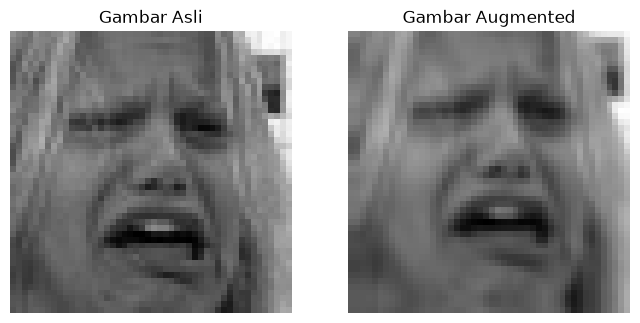

In [7]:
images, labels = next(iter(train_dataset))

original_image = images[0]

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_image, cmap="gray")
plt.title("Gambar Asli")
plt.axis("off")

augmented_image = data_augmentation(
    tf.expand_dims(original_image, axis=0),
    training=True
)[0]

plt.subplot(1, 2, 2)
plt.imshow(augmented_image, cmap="gray")
plt.title("Gambar Augmented")
plt.axis("off")

plt.show()

In [8]:
model = Sequential([
    data_augmentation,

    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(48, 48, 1)
    ),
    MaxPooling2D((2, 2)),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),
    Dropout(0.5),

    Dense(
        7,
        activation="softmax"
    )
])

model.summary()

d:\JamTerbang\DL\KlasifikasiEkspresi\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 48, 48, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 46, 46, 32)        │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 23, 23, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 21, 21, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 10, 10, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 6400)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 7)                 │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 839,047 (3.20 MB)

 Trainable params: 839,047 (3.20 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20
)

Epoch 1/20


d:\JamTerbang\DL\KlasifikasiEkspresi\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


686/686 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.2673 - loss: 1.7750 - val_accuracy: 0.3335 - val_loss: 1.6993
Epoch 2/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.3160 - loss: 1.7010 - val_accuracy: 0.3753 - val_loss: 1.6057
Epoch 3/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.3529 - loss: 1.6457 - val_accuracy: 0.4164 - val_loss: 1.5185
Epoch 4/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.3699 - loss: 1.6043 - val_accuracy: 0.4363 - val_loss: 1.4659
Epoch 5/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.3906 - loss: 1.5655 - val_accuracy: 0.4461 - val_loss: 1.4488
Epoch 6/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.3962 - loss: 1.5420 - val_accuracy: 0.4549 - val_loss: 1.4189
Epoch 7/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.4104 - loss: 1.5166 - val_accuracy: 0.4527 - val_loss: 1.4071
Epoch 8/20
686/686 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.4162 - loss: 1.5056 - val_accurac

In [11]:
y_true_aug = []
y_pred_aug = []

for images, labels in val_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true_aug.extend(labels.numpy())
    y_pred_aug.extend(predicted_labels)

y_true_aug = np.array(y_true_aug)
y_pred_aug = np.array(y_pred_aug)

print("Jumlah data validation:", len(y_true_aug))

Jumlah data validation: 5487


In [12]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_aug,
        y_pred_aug,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       angry       0.39      0.41      0.40       767
     disgust       0.00      0.00      0.00        76
        fear       0.41      0.19      0.26       777
       happy       0.66      0.80      0.72      1417
     neutral       0.40      0.57      0.47       973
         sad       0.39      0.25      0.30       943
    surprise       0.55      0.64      0.59       534

    accuracy                           0.50      5487
   macro avg       0.40      0.41      0.39      5487
weighted avg       0.47      0.50      0.47      5487



d:\JamTerbang\DL\KlasifikasiEkspresi\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\JamTerbang\DL\KlasifikasiEkspresi\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\JamTerbang\DL\KlasifikasiEkspresi\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

## Kesimpulan Experiment Data Augmentation

Data augmentation berhasil mengurangi perbedaan antara performa training dan validation, tetapi belum meningkatkan performa validation secara keseluruhan.

Validation accuracy terbaik sebesar 49.70%, lebih rendah dibandingkan baseline sebesar 51.08%. Macro F1 juga turun dari 0.43 menjadi 0.39.

Performa kelas Disgust mengalami penurunan yang signifikan. Recall dan F1-score Disgust menjadi 0.00 karena model tidak menghasilkan prediksi untuk kelas tersebut pada validation set.

Berdasarkan hasil tersebut, data augmentation saja belum cukup untuk mengatasi masalah class imbalance dan klasifikasi ekspresi pada model CNN baseline.